In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from pandas_base.data_generator import data_generator
from custom_generator import SmartPreprocessor
from imblearn.over_sampling import SMOTE

In [2]:
file_path = "assets/credit_card_fraud.csv"

In [3]:
df = pd.read_csv(file_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


In [5]:
for X_batch, y_batch in data_generator(filepath=file_path, target="Class"):
    X_train, X_test, y_train, y_test = train_test_split(X_batch, y_batch, test_size=0.2, random_state=42)


In [6]:
preprocessor = SmartPreprocessor()
preprocessor.fit(X_train)
res = preprocessor.transform(X_train)

In [7]:
res

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
278,15571284,1,3.521348,1.252763,1.098612,13,8,1.321756,1,1,1.945910,0,1.098612,5.081404,7.637234
110,15688210,1,3.669951,2.409195,0.693147,4,4,0.117783,0,0,0.000000,0,1.098612,5.081404,0.693147
82,15672894,0,2.974509,2.397895,1.098612,2,4,0.347130,0,0,0.000000,0,1.098612,4.394449,3.784190
51,15720529,1,3.094672,1.634131,0.693147,3,8,0.039221,0,0,0.000000,0,1.098612,4.948760,4.624973
218,15720353,1,3.020425,0.254642,1.098612,4,4,0.254642,0,0,0.000000,0,1.098612,5.638355,5.902633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,15608595,0,3.447445,0.864997,1.098612,9,8,0.039221,0,1,1.386294,0,1.098612,0.000000,3.555348
106,15597536,1,3.355851,1.098612,1.098612,14,8,0.693147,1,1,1.609438,0,1.098612,4.948760,8.928773
270,15675926,0,3.004196,1.858639,1.098612,3,8,0.254642,0,0,0.000000,0,1.098612,4.394449,6.186209
435,15687527,1,2.837908,0.559616,1.098612,8,4,1.011601,1,1,1.791759,1,1.098612,5.866468,6.539586


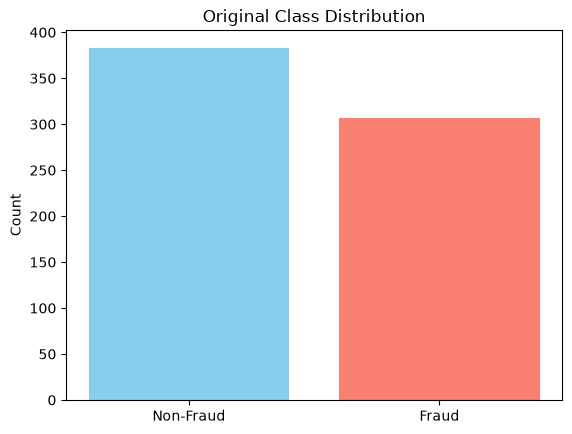

In [9]:
plt.bar(y_batch.value_counts().index, y_batch.value_counts().values, color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.ylabel("Count")
plt.title("Original Class Distribution")
plt.show()

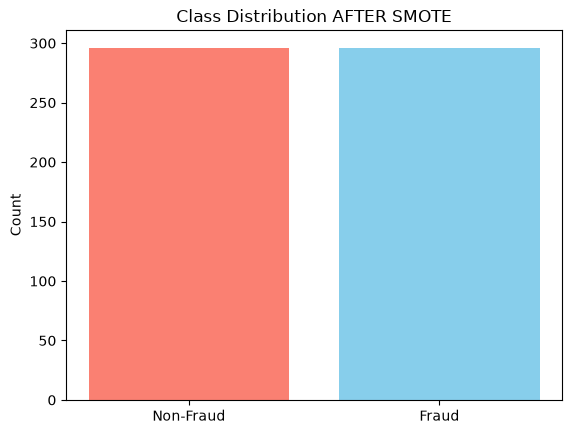

In [10]:
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values,
        color=['skyblue','salmon'])
plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()